# HL-CUP25 Heterogeneous Ensemble

In [27]:
# --- IMPORTS ---
import os
# Set Keras Backend to PyTorch BEFORE importing anything that might use Keras
os.environ["KERAS_BACKEND"] = "torch"

import time
import json
import torch
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import keras

# Custom Modules
from utils.data_loader import get_ml_cup_data
from models import StandardFeedForwardNet, ModelWithHead, ReadoutAdapter
from utils.training_utils import evaluate, evaluate_mee
import utils.training_utils as training_utils
from executors.executors import build_model_single_hidden, build_model_two_hidden

print("Imports successful. Keras Backend set to torch.")

# Global Plot Settings
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'


Imports successful. Keras Backend set to torch.


In [7]:
# --- CONFIGURATION ---
BATCH_SIZE_KERAS = 80
BATCH_SIZE_PYTORCH = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Ensemble Settings
ENSEMBLE_SIZE_PYTORCH = 5
ENSEMBLE_SIZE_KERAS = 5
ENSEMBLE_SIZE_SVM = 5

# Results CSV Pointers (Link your specific result files here)
# Set to None to try finding them automatically
PYTORCH_RESULTS_CSV = "pytorch/models/optuna/20_01_2026(2layer)/optuna_results.csv"
KERAS_RESULTS_CSV = "keras/models/optuna_results.csv"
SVM_RESULTS_DIR = "svm/models/FineTuned/SVR_1"  # Folder containing svr_target_*_trials.csv

USE_GAUSSIAN_NOISE = True # Enforcing diversity via noise for retraining
NOISE_STD = 0.1


# Early Stopping
EARLY_STOPPING_PATIENCE = 250
print(f"Device: {DEVICE}")


Device: mps


In [3]:
# --- CUSTOM CLASS: MULTI-OUTPUT SVR ---
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.svm import SVR

class MultiOutputSVR(BaseEstimator, RegressorMixin):
    """
    A wrapper that holds 4 independent SVR models (one per target).
    This allows us to treat the 4-target regressor as a single 'Model' in the ensemble list.
    """
    def __init__(self, estimators_list=None):
        # estimators_list: list of 4 SVR instances (configured with their specific params)
        self.estimators_list = estimators_list
        self.fitted_estimators_ = []

    def fit(self, X, y):
        # X: (N, F), y: (N, 4)
        self.fitted_estimators_ = []
        n_targets = y.shape[1]
        
        if len(self.estimators_list) != n_targets:
            raise ValueError(f"Expected {n_targets} estimators, got {len(self.estimators_list)}")
            
        for i in range(n_targets):
            est = clone(self.estimators_list[i])
            est.fit(X, y[:, i])
            self.fitted_estimators_.append(est)
            
        return self

    def predict(self, X):
        preds = []
        for est in self.fitted_estimators_:
            preds.append(est.predict(X))
        return np.column_stack(preds)


In [4]:
# --- ENSEMBLE CLASS ---
class HeterogeneousEnsemble:
    def __init__(self, pytorch_models, keras_models, svm_models, target_scaler=None):
        self.pytorch_models = pytorch_models
        self.keras_models = keras_models
        self.svm_models = svm_models 
        self.target_scaler = target_scaler
        
    def eval(self):
        """Mock eval method to satisfy evaluate_mee"""
        pass

    def __call__(self, x):
        """Allows the ensemble to be called like a tensor function: model(x)"""
        if isinstance(x, torch.Tensor):
            x_np = x.detach().cpu().numpy()
        else:
            x_np = x
            
        # Get predictions (SCALED)
        pred_np = self.predict(x_np)
        
        # Return as tensor
        return torch.tensor(pred_np, dtype=torch.float32, device=DEVICE)

    def predict(self, X_numpy):
        # Accumulate predictions in SCALED space
        preds = []
        
        # 1. PyTorch
        if self.pytorch_models:
            X_torch = torch.tensor(X_numpy, dtype=torch.float32).to(DEVICE)
            for i, m in enumerate(self.pytorch_models):
                m.eval()
                with torch.no_grad():
                    out = m(X_torch).cpu().numpy()
                    # print(f"DEBUG: PyTorch Model {i} Mean={out.mean():.4f} Std={out.std():.4f}")
                    preds.append(out)
                    
        # 2. Keras
        if self.keras_models:
            for i, m in enumerate(self.keras_models):
                out = m.predict(X_numpy, verbose=0)
                # print(f"DEBUG: Keras Model {i} Mean={out.mean():.4f} Std={out.std():.4f}")
                preds.append(out)
        
        # 3. SVM
        if self.svm_models:
            for i, m in enumerate(self.svm_models):
                out = m.predict(X_numpy)
                # print(f"DEBUG: SVM Model {i} RAW Mean={out.mean():.4f} Std={out.std():.4f}")
                
                if self.target_scaler:
                    if out.ndim == 1:
                        out = out.reshape(-1, 1)
                    # print(f"DEBUG: Target Transform Mean={self.target_scaler.mean_} Scale={self.target_scaler.scale_}")     
                    out = self.target_scaler.transform(out)
                    # print(f"DEBUG: SVM Model {i} SCALED Mean={out.mean():.4f} Std={out.std():.4f}")
                    
                preds.append(out)

        if not preds:
            return np.zeros((X_numpy.shape[0], OUTPUT_SIZE))
            
        # Check consistency
        preds_np = np.array(preds)
        # print(f"DEBUG: Ensemble Preds Shape {preds_np.shape}. Mean of means: {np.mean(preds_np, axis=0).mean():.4f}")
        
        # Return MEAN of scaled predictions
        return np.mean(preds, axis=0)


In [8]:
# --- EARLY STOPPING CLASS ---
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0, mode='min'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.mode = mode
        self.best_score = None
        self.early_stop = False
        self.best_state = None

    def __call__(self, score, model=None):
        if self.best_score is None:
            self.best_score = score
            if model: self.best_state = model.state_dict()
        elif self._is_better(score, self.best_score):
            self.best_score = score
            self.counter = 0
            if model: self.best_state = model.state_dict()
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def _is_better(self, current, best):
        if self.mode == 'min':
            return current < (best - self.min_delta)
        else:
            return current > (best + self.min_delta)

## Part 1: Ensemble selection 

In [ ]:
# --- DATA LOADING ---
# Load ML-CUP Data
train_loader, val_loader, test_loader, INPUT_SIZE, OUTPUT_SIZE, target_scaler = get_ml_cup_data(
    BATCH_SIZE_PYTORCH, 
    validation_ratio=0.20,
    test_ratio=0.25,
    scale_target=True,
    num_workers=0
)

print(f"Data Loaded. Input: {INPUT_SIZE}, Output: {OUTPUT_SIZE}")

# --- PREPARE K-FOLD DATA ---
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset, DataLoader

# Merge Train and Val for K-Fold
# Note: get_ml_cup_data returns Loaders. We access underlying dataset tensors.
X_train_main = train_loader.dataset.X
y_train_main = train_loader.dataset.y
X_val_main = val_loader.dataset.X
y_val_main = val_loader.dataset.y

X_dev = torch.cat([X_train_main, X_val_main], dim=0)
y_dev = torch.cat([y_train_main, y_val_main], dim=0)

print(f"Merged Development Set: {X_dev.shape}")

# Initialize K-Fold
# n_splits matches ENSEMBLE_SIZE_PYTORCH so each model gets a different fold config.
if ENSEMBLE_SIZE_PYTORCH > 0:
    kf = KFold(n_splits=ENSEMBLE_SIZE_PYTORCH, shuffle=True, random_state=42)
    folds = list(kf.split(X_dev))
    print(f"Created {len(folds)} folds for PyTorch Ensemble.")


NameError: name 'BATCH_SIZE' is not defined

In [ ]:
# --- HELPER: IMPORT HYPERPARAMETERS FROM STUDIES ---
import optuna
import glob
import json
import os
import pandas as pd
import ast

# --- CONFIGURATION: PARAMETER LIMIT CHECK ---
LIMIT_PARAMS = False   # Set to True to activate the filter
LIMIT_COUNT = 900
INPUT_DIM = 12            # REPLACE with your dataset's output size (number of targets)
OUTPUT_DIM = 4            # REPLACE with your dataset's output size (number of targets)

def get_model_params(row):
    """
    Calculates total parameters (Weights + Biases) for an MLP.
    Formula: 
      1. Input -> Hidden 1: (In * Hid) + Hid
      2. Hidden -> Hidden:  (Hid * Hid) + Hid  (for n_layers - 1)
      3. Hidden -> Output:  (Hid * Out) + Out
    """
    n_layers = int(row.get('params_n_layers', 2)) # Default to 2 if missing
    hidden_size = int(row['params_hidden_size'])
    
    # Layer 1: Input -> Hidden
    total_params = (INPUT_DIM * hidden_size) + hidden_size
    
    # Middle Layers: Hidden -> Hidden
    if n_layers > 1:
        total_params += (n_layers - 1) * ((hidden_size * hidden_size) + hidden_size)
        
    # Output Layer: Hidden -> Output
    total_params += (hidden_size * OUTPUT_DIM) + OUTPUT_DIM
    
    return total_params

def load_best_params():
    params = {}
    
    # 1. PYTORCH
    try:
        if PYTORCH_RESULTS_CSV and os.path.exists(PYTORCH_RESULTS_CSV):
            df = pd.read_csv(PYTORCH_RESULTS_CSV)

            # --- CHECK: Filter for model complexity ---
            if LIMIT_PARAMS:
                print(f"[PyTorch] Filtering for models with < {LIMIT_COUNT} parameters...")
                
                # Calculate parameters for every row
                df['calculated_params'] = df.apply(get_model_params, axis=1)
                
                # Filter the dataframe
                df_constrained = df[df['calculated_params'] < LIMIT_COUNT]
                
                if not df_constrained.empty:
                    print(f"  > Found {len(df_constrained)} trials matching criteria.")
                    df = df_constrained
                else:
                    print(f"  > WARNING: No trials found with < {LIMIT_COUNT} params. Reverting to all trials.")
            # ------------------------------------------

            best_idx = df['value'].idxmin()
            best_row = df.loc[best_idx]
            p_dict = {k.replace('params_', ''): v for k, v in best_row.items() if k.startswith('params_')}
            params['pytorch'] = p_dict
            
            # Log info about selected model
            sel_val = best_row['value']
            # Use calculated params if available, otherwise calculate it now for display
            sel_params = best_row['calculated_params'] if 'calculated_params' in best_row else get_model_params(best_row)
            
            print(f"Loaded PyTorch Best Params (Loss: {sel_val:.4f}, Size: {sel_params}): {params['pytorch']}")
            
        else:
             # Fallback for SQL (Cannot easily filter by calculated params without loading all)
             storage = "sqlite:///optuna_mlcup_nn.db"
             if os.path.exists("optuna_mlcup_nn.db"):
                 study = optuna.load_study(study_name="mlcup_search", storage=storage)
                 params['pytorch'] = study.best_params
                 print(f"Loaded PyTorch Best Params from DB: {params['pytorch']}")
             else:
                 params['pytorch'] = None
    except Exception as e:
        print(f"Could not load PyTorch params: {e}")
        params['pytorch'] = None

    # 2. KERAS
    if KERAS_RESULTS_CSV and os.path.exists(KERAS_RESULTS_CSV):
        try:
            print(f"Loading Keras results from {KERAS_RESULTS_CSV}...")
            df = pd.read_csv(KERAS_RESULTS_CSV)
            # Filter valid trials
            df = df[df['state'] == 'COMPLETE']
            # Sort by value (ascending for minimization)
            df = df.sort_values(by='value', ascending=True)
            
            if not df.empty:
                best_row = df.iloc[0]
                # Extract params
                p_dict = {k.replace('params_', ''): v for k, v in best_row.items() if k.startswith('params_')}
                params['keras'] = p_dict
                print(f"Loaded Keras Best Params (Val={best_row['value']:.4f}): {params['keras']}")
            else:
                print("Keras results CSV found but no complete trials.")
                params['keras'] = None
        except Exception as e:
            print(f"Error loading Keras CSV: {e}")
            params['keras'] = None
    else:
        # Fallback: Check for hp.json in subfolders (backward compatibility)
        keras_files = glob.glob("keras/models/optuna/**/hp.json", recursive=True)
        if keras_files:
            latest_file = max(keras_files, key=os.path.getmtime)
            with open(latest_file, 'r') as f:
                params['keras'] = json.load(f)
            print(f"Loaded Keras Best Params from {latest_file}: {params['keras']}")
        else:
            params['keras'] = None

    # 3. SVM (Unchanged logic)
    print("Scanning for SVM results...")
    svm_base_dir = "svm/models"
    all_csvs = glob.glob(os.path.join(svm_base_dir, "**", "*trials.csv"), recursive=True)
    
    best_svm = {}
    if all_csvs:
        for t_idx in range(4): # 4 targets
            target_str = f"target_{t_idx}"
            target_dfs = []
            
            for fpath in all_csvs:
                 if target_str in os.path.basename(fpath):
                     try:
                         df_t = pd.read_csv(fpath)
                         target_dfs.append(df_t)
                     except: pass
            
            if target_dfs:
                full_df = pd.concat(target_dfs, ignore_index=True)
                full_df = full_df.sort_values(by='value', ascending=False)
                best_row = full_df.iloc[0]
                p_dict = {k.replace('params_', ''): v for k, v in best_row.items() if k.startswith('params_')}
                best_svm[target_str] = p_dict
                print(f"  {target_str}: Best Value={best_row['value']:.4f} Params={p_dict}")
            else:
                best_svm[target_str] = None
        params['svm'] = best_svm
    else:
         print("No SVM CSVs found.")
         params['svm'] = None
         
    return params

START_PARAMS = load_best_params()

In [ ]:
# --- ROBUST INITIALIZATION ---
# Initialize model lists to empty to avoid NameError if specific sections are skipped.
pytorch_models = []
keras_models = []
svm_models = []
print("Model lists initialized to empty.")


In [ ]:
# --- PART 1: PYTORCH MODELS ---
BATCH_SIZE = 64
pytorch_models = []
pytorch_histories = {'train_mee': [], 'val_mee': []}

if START_PARAMS['pytorch']:
    print(f"Using Loaded PyTorch Params: {START_PARAMS['pytorch']}")
    pt_params = START_PARAMS['pytorch'].copy()
else:
    print("Using Default PyTorch Params.")
    # Added default dropout here
    pt_params = {'hidden_size': 32, 'lr': 0.01, 'momentum': 0.9, 'activation': 'relu', 'dropout': 0.0}

def train_pytorch_model_with_tracking(idx):
    print(f"Training PyTorch Model {idx+1}/{ENSEMBLE_SIZE_PYTORCH} (Fold {idx+1})...")
    
    # 1. Get Data for this Fold
    train_idx, val_idx = folds[idx]
    X_f_train, y_f_train = X_dev[train_idx], y_dev[train_idx]
    X_f_val, y_f_val = X_dev[val_idx], y_dev[val_idx]
    
    # Create Loader for shuffling
    f_dataset = TensorDataset(X_f_train, y_f_train)
    f_loader = DataLoader(f_dataset, batch_size=BATCH_SIZE_PYTORCH, shuffle=True)
    
    # 2. Build Model
    # Get the number of layers (default to 2 if not found)
    if pt_params.get('n_layers') is None: 
        n_layers = 2
    else:
        n_layers = int(pt_params.get('n_layers', 2)) 
    # Get the size of the layers
    layer_size = int(pt_params.get('hidden_size', 32))
    # Create the list (e.g., if n_layers=3, hidden_sizes=[32, 32, 32])
    hidden_sizes = [layer_size] * n_layers
    act = pt_params.get('activation', 'relu')
    dropout_val = float(pt_params.get('dropout', 0.0))
    
    # Instantiate Base with Dropout
    # Assuming StandardFeedForwardNet accepts 'dropout' as an argument
    base = StandardFeedForwardNet(INPUT_SIZE, hidden_sizes, OUTPUT_SIZE, act, dropout=dropout_val)
    model = ModelWithHead(base, ReadoutAdapter(OUTPUT_SIZE, OUTPUT_SIZE, 'regression')).to(DEVICE)
    
    lr = float(pt_params.get('lr', 0.01))
    mom = float(pt_params.get('momentum', 0.9))
    
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=mom, nesterov=True)
    crit = torch.nn.MSELoss()
    
    # Trackers
    fold_train_mee = []
    fold_val_mee = []
    
    # 3. Training Loop
    epochs = int(pt_params.get('epochs', 1000))
    print(f"Training for {epochs} epochs...")
    early_stopper = EarlyStopper(patience=EARLY_STOPPING_PATIENCE, mode='min')
    for epoch in range(epochs):
        model.train() # Enable Dropout
        for x, y in f_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if USE_GAUSSIAN_NOISE:
                noise = torch.randn_like(x) * NOISE_STD
                x = x + noise
            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()
        
        # --- MEE EVALUATION (Every Epoch) ---
        # Evaluate on full fold arrays (Unscaled)
        model.eval() # Disable Dropout for Evaluation
        with torch.no_grad():
            # Prepare Data
            x_tr_d = X_f_train.to(DEVICE)
            x_val_d = X_f_val.to(DEVICE)
            
            # Predict
            pred_tr = model(x_tr_d).cpu().numpy()
            pred_val = model(x_val_d).cpu().numpy()
            
            # Unscale Targets & Predictions
            y_tr_real = target_scaler.inverse_transform(y_f_train.numpy())
            pred_tr_real = target_scaler.inverse_transform(pred_tr)
            
            y_val_real = target_scaler.inverse_transform(y_f_val.numpy())
            pred_val_real = target_scaler.inverse_transform(pred_val)
            
            # Calculate Mean Euclidean Error
            mee_tr = np.mean(np.linalg.norm(y_tr_real - pred_tr_real, axis=1))
            mee_val = np.mean(np.linalg.norm(y_val_real - pred_val_real, axis=1))
            
            fold_train_mee.append(mee_tr)
            fold_val_mee.append(mee_val)
            
            # EARLY STOPPING CHECK
            early_stopper(mee_val, model)
            if early_stopper.early_stop:
                print(f"  Early stopping at epoch {epoch} (Best MEE: {early_stopper.best_score:.4f})")
                break
            
    
    # Load Best Weights if check triggered, otherwise keep last
    if early_stopper.best_state:
        model.load_state_dict(early_stopper.best_state)
            
    return model, fold_train_mee, fold_val_mee

start_time = time.time()
actual_runs = min(ENSEMBLE_SIZE_PYTORCH, len(folds))

for i in range(actual_runs):
    model, tr_hist, val_hist = train_pytorch_model_with_tracking(i)
    pytorch_models.append(model)
    pytorch_histories['train_mee'].append(tr_hist)
    pytorch_histories['val_mee'].append(val_hist)

print(f"PyTorch Ensemble Training Time: {time.time() - start_time:.2f}s")

In [ ]:
# --- PLOT TRAINING MEE ---
plt.figure(figsize=(14, 6))

# Subplot 1: Training MEE
plt.subplot(1, 2, 1)
for i, curve in enumerate(pytorch_histories['train_mee']):
    plt.plot(curve, label=f'Model {i+1} (Fold {i+1})', alpha=0.6)
plt.title("PyTorch Ensemble: Training MEE (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MEE")
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

# Subplot 2: Validation MEE
plt.subplot(1, 2, 2)
for i, curve in enumerate(pytorch_histories['val_mee']):
    plt.plot(curve, label=f'Model {i+1} (Fold {i+1})', alpha=0.6)
plt.title("PyTorch Ensemble: Validation MEE (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MEE")
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- CUSTOM KERAS CALLBACK: MEE TRACKING ---
class MEE_Callback(keras.callbacks.Callback):
    def __init__(self, X_val, y_val, target_scaler=None, patience=None, min_delta=0):
        super(MEE_Callback, self).__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.target_scaler = target_scaler
        self.train_mee = []
        self.val_mee = []
        
        self.patience = patience
        self.min_delta = min_delta
        self.wait = 0
        self.best_mee = float('inf')
        self.stopped_epoch = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        pass 
        y_pred = self.model.predict(self.X_val, verbose=0)
        
        if self.target_scaler:
            y_true_real = self.target_scaler.inverse_transform(self.y_val)
            y_pred_real = self.target_scaler.inverse_transform(y_pred)
        else:
            y_true_real = self.y_val
            y_pred_real = y_pred
            
        val_mee = np.mean(np.linalg.norm(y_true_real - y_pred_real, axis=1))
        self.val_mee.append(val_mee)
        logs['val_mee'] = val_mee
        
        if self.patience:
            if val_mee < (self.best_mee - self.min_delta):
                self.best_mee = val_mee
                self.wait = 0
                self.best_weights = self.model.get_weights()
            else:
                self.wait += 1
                if self.wait >= self.patience:
                    self.stopped_epoch = epoch
                    self.model.stop_training = True
                    print(f"\n  Early stopping at epoch {epoch} (Best MEE: {self.best_mee:.4f})")
                    if self.best_weights:
                        self.model.set_weights(self.best_weights)

# --- PART 2: KERAS MODELS ---
keras_models = []
keras_histories = {'val_mee': []}

if START_PARAMS['keras']:
    print(f"Using Loaded Keras Params: {START_PARAMS['keras']}")
    k_params = START_PARAMS['keras']
    k_meta = {"n_features_in_": INPUT_SIZE, "n_outputs_": OUTPUT_SIZE}
    
    def train_keras_model(idx):
        print(f"Training Keras Model {idx+1}/{ENSEMBLE_SIZE_KERAS}...")
        seed = 42 + idx
        
        lr = k_params.get('learning_rate', 0.01)
        l1 = k_params.get('lambda_1', 1e-4)
        act1 = k_params.get('activation_1', 'relu')
        drop1 = k_params.get('dropout_1', 0.2)
        
        l2 = k_params.get('lambda_2', None)
        if l2: 
            u1 = k_params.get('unit1', 12)
            u2 = k_params.get('unit2', 12)
            act2 = k_params.get('activation_2', 'relu')
            drop2 = k_params.get('dropout_2', 0.2)
            model = build_model_two_hidden(k_meta, u1, u2, seed, lr, drop1, drop2, l1, l2, act1, act2)
        else:
            u1 = k_params.get('unit1', 12)
            model = build_model_single_hidden(k_meta, u1, seed, lr, drop1, l1, act1)
            
        X_tr = X_dev.numpy()
        y_tr = y_dev.numpy()
        
        # --- UNSCALE TARGETS for Keras ---
        if target_scaler:
           y_tr = target_scaler.inverse_transform(y_tr)

        if USE_GAUSSIAN_NOISE:
             noise = np.random.normal(0, NOISE_STD, X_tr.shape)
             X_tr = X_tr + noise
             
        # Split for Validation
        split_idx = int(0.8 * len(X_tr))
        X_t, X_v = X_tr[:split_idx], X_tr[split_idx:]
        y_t, y_v = y_tr[:split_idx], y_tr[split_idx:]
        
        # Pass target_scaler=None because X_v/y_v are already in real features/targets space (model predicts real)
        # Wait, X_v is SCALED features (Models expect scaled inputs), y_v is UNSCALED targets.
        # Callback expects: y_val (True Unscaled) and Model Prediction (Unscaled).
        # So we pass target_scaler=None to callback so it doesn't try to inverse_transform again.
        mee_cb = MEE_Callback(X_v, y_v, target_scaler=None, patience=EARLY_STOPPING_PATIENCE)
        
        model.fit(X_t, y_t, epochs=600, verbose=0, batch_size=BATCH_SIZE_KERAS, callbacks=[mee_cb])
        return model, mee_cb.val_mee

    for i in range(ENSEMBLE_SIZE_KERAS):
         try:
             model, h_val = train_keras_model(i)
             keras_models.append(model)
             keras_histories['val_mee'].append(h_val)
         except Exception as e:
             print(f"Keras Train Error: {e}")
             
else:
    print("No Keras Params loaded. Skipping Keras.")


In [ ]:
# --- PLOT KERAS MEE ---
if keras_models:
    plt.figure(figsize=(7, 6))
    for i, curve in enumerate(keras_histories['val_mee']):
        plt.plot(curve, label=f'Model {i+1}', alpha=0.6)
    plt.title("Keras Ensemble: Validation MEE (Part 1)")
    plt.xlabel("Epoch")
    plt.ylabel("MEE")
    plt.yscale('log')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.show()


In [ ]:
# --- PART 3: SVM MODELS ---
from sklearn.ensemble import BaggingRegressor

svm_models = [] # Will contain a single MultiOutputSVR that wraps 4 BaggingRegressors

if START_PARAMS['svm']:
    print(f"Training SVM Ensemble with Bagging (n_estimators={ENSEMBLE_SIZE_SVM})...")
    svm_params_dict = START_PARAMS['svm']
    
    X_tr = X_dev.numpy()
    y_tr = y_dev.numpy()
    
    # --- CRITICAL FIX: Inverse Scale Targets for SVM ---
    # SVM hyperparameters were optimized on UNSCALED targets.
    # We must ensure we train on the same distribution.
    if target_scaler:
        print("Inverse scaling targets for SVM training...")
        y_tr = target_scaler.inverse_transform(y_tr)
    # ---------------------------------------------------
    
    estimators_list = []
    valid_svm = True
    
    for t_idx in range(OUTPUT_SIZE):
        target_key = f"target_{t_idx}"
        conf = svm_params_dict.get(target_key)
        
        if not conf:
            print(f"Missing params for {target_key}, skipping SVM.")
            valid_svm = False
            break
            
        # 1. Base SVR
        base_svr = SVR(kernel='rbf', C=conf.get('C', 1.0), epsilon=conf.get('epsilon', 0.1), gamma=conf.get('gamma', 'scale'))
        
        # 2. Wrap in BaggingRegressor
        # exact logic from svm_analysis.ipynb usually
        regr = BaggingRegressor(
            estimator=base_svr,
            n_estimators=ENSEMBLE_SIZE_SVM, 
            random_state=42 + t_idx,
            max_samples=0.8, # Subsample for diversity
            bootstrap=True,
            n_jobs=-1
        )
        estimators_list.append(regr)
    
    if valid_svm:
        # Wrap 4 BaggingRegressors into one Multi-Output Model
        print("Fitting Bagged SVMs...")
        msvr = MultiOutputSVR(estimators_list=estimators_list)
        msvr.fit(X_tr, y_tr)
        
        svm_models.append(msvr)
        print("SVM Training Complete.")
    
else:
    print("No SVM params loaded. Skipping.")


In [ ]:
# --- INTERNAL EVALUATION ---
full_ensemble = HeterogeneousEnsemble(pytorch_models, keras_models, svm_models, target_scaler=target_scaler)

X_test_np = test_loader.dataset.X.numpy()
y_test_np = test_loader.dataset.y.numpy()

print("Evaluating Ensemble on Internal Test Set...")

# Calculate MEE
# IMPORTANT: Pass target_scaler to unscale both predictions and targets
mee = evaluate_mee(full_ensemble, test_loader, DEVICE, target_scaler=target_scaler)
print(f"Ensemble Internal Test MEE: {mee:.4f}")

# --- SAVE BEST ENSEMBLE LOGIC ---
best_score_file = "ensemble_best_score.json"
current_best = float('inf')
if os.path.exists(best_score_file):
    with open(best_score_file, 'r') as f:
        try:
            data = json.load(f)
            current_best = data.get('best_mee', float('inf'))
        except: pass

print(f"Previous Best MEE: {current_best:.4f}")

if mee < current_best:
    print("New Best Ensemble found! Saving configuration to JSON...")
    
    # Save Configuration ONLY (No weights)
    ensemble_config = {
        'best_mee': float(mee),
        'timestamp': time.strftime("%Y-%m-%d %H:%M:%S"),
        'config': {
            'pytorch': {
                'count': ENSEMBLE_SIZE_PYTORCH,
                'params': START_PARAMS['pytorch'],
                'epochs': int(pt_params.get('epochs', 1200)) if 'pt_params' in globals() else 1200
            },
            'keras': {
                'count': ENSEMBLE_SIZE_KERAS,
                'params': START_PARAMS['keras']
            },
            'svm': {
                'count': ENSEMBLE_SIZE_SVM,
                'params': START_PARAMS['svm']
            }
        }
    }
    
    # Save best parameters to JSON
    with open("best_ensemble_config.json", 'w') as f:
        json.dump(ensemble_config, f, indent=4, default=lambda o: o.item())

        
    # Update score file for tracking
    with open(best_score_file, 'w') as f:
        json.dump({'best_mee': float(mee)}, f)
        
    print("Configuration saved to best_ensemble_config.json")
else:
    print("Ensemble did not improve over best recorded score.")

## Part 2: blind test set

In [23]:
# --- SETUP FOR PART 2 ---
# We need to reconstruct the full dataset (Dev + Test) for the final retraining
# and load the best configuration found in Part 1.

# 1. Load Best Config
if os.path.exists("best_ensemble_config.json"):
    with open("best_ensemble_config.json", 'r') as f:
        best_conf = json.load(f)
    pt_conf = best_conf['config']['pytorch']
    k_conf = best_conf['config']['keras']
    svm_conf = best_conf['config']['svm']
    print("Loaded best_ensemble_config.json")
else:
    print("WARNING: best_ensemble_config.json not found. Retraining might fail or use defaults.")
    pt_conf = {'count': 0, 'params': None}
    k_conf = {'count': 0, 'params': None}
    svm_conf = {'count': 0, 'params': None}

# 2. Prepare Full Data (Train + Val + Internal Test)
# Note: train_loader, val_loader, test_loader are already available from Part 1
X_train_np = train_loader.dataset.X
y_train_np = train_loader.dataset.y
X_val_np = val_loader.dataset.X
y_val_np = val_loader.dataset.y
X_test_np = test_loader.dataset.X
y_test_np = test_loader.dataset.y

# Concatenate all to get X_full, y_full
X_full = torch.cat([X_train_np, X_val_np, X_test_np], dim=0)
y_full = torch.cat([y_train_np, y_val_np, y_test_np], dim=0)

print(f"Full Retraining Dataset: {X_full.shape}")

# Re-fit scaler on FULL data for final consistency (optional but recommended)
# FIX: Do NOT re-fit scaler on already scaled data. Use the original scaler from Part 1.
# from sklearn.preprocessing import StandardScaler
# target_scaler_full = StandardScaler()
# target_scaler_full.fit(y_full.numpy())
target_scaler_full = target_scaler
print("Using original target_scaler from Part 1.")


Loaded best_ensemble_config.json
Full Retraining Dataset: torch.Size([500, 12])
Using original target_scaler from Part 1.


In [ ]:
# --- 3. RETRAIN PYTORCH (K-Fold on Full Data) ---
pytorch_models_full = []
pytorch_retrain_histies = {'train_mee': [], 'val_mee': []}

if pt_conf['count'] > 0 and pt_conf.get('params'):
    print(f"\nRetraining {pt_conf['count']} PyTorch Models (K-Fold on Full Data)...")
    p_params = pt_conf['params']
    epochs_conf = int(pt_conf.get('epochs', 1200))
    kf_full = KFold(n_splits=pt_conf['count'], shuffle=True, random_state=42)
    folds_full = list(kf_full.split(X_full))
    
    for idx in range(pt_conf['count']):
        train_idx, val_idx = folds_full[idx]
        X_f_train, y_f_train = X_full[train_idx], y_full[train_idx]
        X_f_val, y_f_val = X_full[val_idx], y_full[val_idx]
        
        print(f"  Training PyTorch Full Model {idx+1}/{pt_conf['count']}...")
        f_dataset = TensorDataset(X_f_train, y_f_train)
        f_loader = DataLoader(f_dataset, batch_size=400, shuffle=True)
        
        hidden_sizes = [int(p_params.get('hidden_size', 32))] * int(p_params.get('n_layers', 2))
        act = p_params.get('activation', 'relu')
        dropout_val = float(p_params.get('dropout', 0.0))
        base = StandardFeedForwardNet(INPUT_SIZE, hidden_sizes, OUTPUT_SIZE, act, dropout=dropout_val)
        model = ModelWithHead(base, ReadoutAdapter(OUTPUT_SIZE, OUTPUT_SIZE, 'regression')).to(DEVICE)
        opt = torch.optim.SGD(model.parameters(), lr=float(p_params.get('lr', 0.01)), momentum=float(p_params.get('momentum', 0.9)), nesterov=True, weight_decay=float(p_params.get('weight_decay', 0.0)))
        crit = torch.nn.MSELoss()
        
        fold_tr_mee = []
        fold_v_mee = []
        early_stopper = EarlyStopper(patience=500, mode='min')
        
        for epoch in range(10000):
            model.train()
            for x, y in f_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                if USE_GAUSSIAN_NOISE:
                    noise = torch.randn_like(x) * NOISE_STD
                    x = x + noise
                opt.zero_grad()
                loss = crit(model(x), y)
                loss.backward()
                opt.step()
            
            model.eval()
            with torch.no_grad():
                x_d = X_f_train.to(DEVICE)
                x_v = X_f_val.to(DEVICE)
                pred_d = model(x_d).cpu().numpy()
                pred_v = model(x_v).cpu().numpy()
                y_d_real = target_scaler_full.inverse_transform(y_f_train.numpy())
                pred_d_real = target_scaler_full.inverse_transform(pred_d)
                y_v_real = target_scaler_full.inverse_transform(y_f_val.numpy())
                pred_v_real = target_scaler_full.inverse_transform(pred_v)
                
                tr_mee = np.mean(np.linalg.norm(y_d_real - pred_d_real, axis=1))
                val_mee = np.mean(np.linalg.norm(y_v_real - pred_v_real, axis=1))
                fold_tr_mee.append(tr_mee)
                fold_v_mee.append(val_mee)
                
                early_stopper(val_mee, model)
                if early_stopper.early_stop:
                    print(f"    Early stopping at epoch {epoch} (Best Val MEE: {early_stopper.best_score:.4f})")
                    break
        
        if early_stopper.best_state:
            model.load_state_dict(early_stopper.best_state)
        pytorch_models_full.append(model)
        pytorch_retrain_histies['train_mee'].append(fold_tr_mee)
        pytorch_retrain_histies['val_mee'].append(fold_v_mee)



Retraining 5 PyTorch Models (K-Fold on Full Data)...
  Training PyTorch Full Model 1/5...
    Early stopping at epoch 4202 (Best Val MEE: 15.8215)
  Training PyTorch Full Model 2/5...
    Early stopping at epoch 1908 (Best Val MEE: 18.9487)
  Training PyTorch Full Model 3/5...
    Early stopping at epoch 2761 (Best Val MEE: 17.5251)
  Training PyTorch Full Model 4/5...
    Early stopping at epoch 2400 (Best Val MEE: 17.2042)
  Training PyTorch Full Model 5/5...
    Early stopping at epoch 1987 (Best Val MEE: 19.6691)


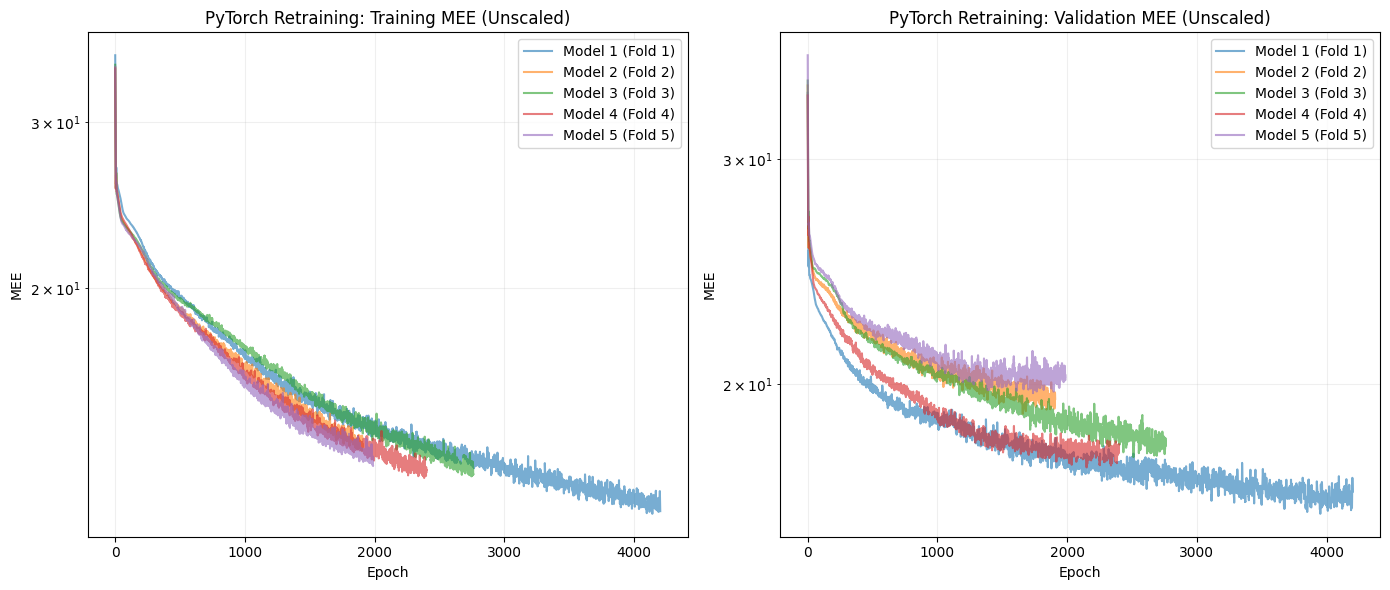

In [37]:
# --- PLOT RETRAINING VALIDATION MEE ---
if pytorch_retrain_histies['train_mee']:
    plt.figure(figsize=(14, 6))

    # Subplot 1: Training MEE
    plt.subplot(1, 2, 1)
    for i, curve in enumerate(pytorch_retrain_histies['train_mee']):
        plt.plot(curve, label=f'Model {i+1} (Fold {i+1})', alpha=0.6)
    plt.title("PyTorch Retraining: Training MEE (Unscaled)")
    plt.xlabel("Epoch")
    plt.ylabel("MEE")
    plt.yscale('log')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()

    # Subplot 2: Validation MEE
    plt.subplot(1, 2, 2)
    for i, curve in enumerate(pytorch_retrain_histies['val_mee']):
        plt.plot(curve, label=f'Model {i+1} (Fold {i+1})', alpha=0.6)
    plt.title("PyTorch Retraining: Validation MEE (Unscaled)")
    plt.xlabel("Epoch")
    plt.ylabel("MEE")
    plt.yscale('log')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No retraining history to plot.")


In [41]:
# --- 4. RETRAIN SVM (K-Fold on Full Data) ---
svm_models_full = []
svm_val_mee_scores = []

if svm_conf is not None and svm_conf.get('count', 0) > 0 and svm_conf.get('params'):
    print(f"Retraining {svm_conf['count']} SVM Models (K-Fold on Full Data)...")
    # Standard K-Fold split
    kf_svm = KFold(n_splits=svm_conf['count'], shuffle=True, random_state=42)
    folds_svm = list(kf_svm.split(X_full))

    for idx in range(svm_conf['count']):
        train_idx, val_idx = folds_svm[idx]
        X_s_train, y_s_train = X_full[train_idx].numpy(), y_full[train_idx].numpy()
        X_s_val, y_s_val = X_full[val_idx].numpy(), y_full[val_idx].numpy()

        # INVERSE TRANSFORM TARGETS for Training
        # SVM params were optimized on UNSCALED data (as per config comment)
        y_s_train_real = target_scaler_full.inverse_transform(y_s_train)
        # Validation GT also needs to be real for MEE calculation
        y_s_val_real = target_scaler_full.inverse_transform(y_s_val)

        # Train 3 (or N_targets) SVRs (one per target output)
        current_fold_models = []
        preds_val = np.zeros_like(y_s_val_real)

        # Check dimensions
        n_targets = y_s_train_real.shape[1]
        print(f"  Training SVM Full Model {idx+1}/{svm_conf['count']} (Targets: {n_targets})...")

        for t_i in range(n_targets):
            p_key = f'target_{t_i}'
            if p_key not in svm_conf['params']:
                 print(f"    WARNING: Missing params for {p_key}! Using default.")
                 cur_params = {'C': 1.0, 'epsilon': 0.1, 'gamma': 'scale'}
            else:
                 cur_params = svm_conf['params'][p_key]
            
            svr = SVR(kernel='rbf', C=cur_params.get('C', 1.0), epsilon=cur_params.get('epsilon', 0.1), gamma=cur_params.get('gamma', 'scale'))
            svr.fit(X_s_train, y_s_train_real[:, t_i])
            current_fold_models.append(svr)
            preds_val[:, t_i] = svr.predict(X_s_val)

        svm_models_full.append(current_fold_models)
        
        # Calculate MEE on Validation Fold
        diff = y_s_val_real - preds_val
        dist = np.linalg.norm(diff, axis=1)
        val_mee = np.mean(dist)
        svm_val_mee_scores.append(val_mee)
        print(f"    Fold {idx+1} Validation MEE: {val_mee:.4f}")

    print("SVM Retraining Complete.")
else:
    print("Skipping SVM Retraining (count=0 or no params).")

Retraining 5 SVM Models (K-Fold on Full Data)...
  Training SVM Full Model 1/5 (Targets: 4)...
    Fold 1 Validation MEE: 15.0967
  Training SVM Full Model 2/5 (Targets: 4)...
    Fold 2 Validation MEE: 17.5879
  Training SVM Full Model 3/5 (Targets: 4)...
    Fold 3 Validation MEE: 15.9521
  Training SVM Full Model 4/5 (Targets: 4)...
    Fold 4 Validation MEE: 16.2664
  Training SVM Full Model 5/5 (Targets: 4)...
    Fold 5 Validation MEE: 18.2093
SVM Retraining Complete.


In [ ]:
# --- PLOT SVM VALIDATION MEE ---
if 'svm_val_mee_scores' in locals() and len(svm_val_mee_scores) > 0:
    plt.figure(figsize=(8, 5))
    folds = range(1, len(svm_val_mee_scores) + 1)
    bars = plt.bar(folds, svm_val_mee_scores, color='orange', alpha=0.7, edgecolor='black')
    plt.title('SVM Ensemble Retraining - Validation MEE per Fold')
    plt.xlabel('Fold')
    plt.ylabel('MEE (Unscaled)')
    plt.xticks(folds)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom')
    
    plt.show()
else:
    print("No SVM validation scores to plot.")

SyntaxError: unexpected character after line continuation character (2573155983.py, line 2)

In [ ]:
# --- BLIND TEST PREDICTION ---
print("Generating Blind Test Output...")

# Load Blind Test Data
blind_df = pd.read_csv("data/MLC25/ML-CUP25-TS.csv", comment='#', header=None)
# Assuming ID is first col? Check template
# Template file: data/MLC25/template-example-with-random-outputs_ML-CUP25-TS.csv
# Usually 1st col ID, rest features.
# Let's inspect shape
print(f"Blind Test Shape: {blind_df.shape}")

# Preprocess
# Remove ID
X_blind = blind_df.iloc[:, 1:].values
ids = blind_df.iloc[:, 0].values

# Scale Input (Must match training data scaling)
# We need the scaler fitted on training data.
# 'train_loader.dataset.transform'? No, dataset stores tensors.
# 'get_ml_cup_data' returns data already scaled if scale_target=True, 
# BUT it scales X and Y independently. X is not returned as a scaler object?
# The loader code handles scaling internally. 
# We need to manually scale X_blind using the statistics of X_train.
X_train_np = train_loader.dataset.X.numpy()
mean = X_train_np.mean(axis=0)
std = X_train_np.std(axis=0) + 1e-8
X_blind_scaled = (X_blind - mean) / std

# Predict
y_blind_pred = full_ensemble.predict(X_blind_scaled)

# Format Output
# Columns: ID, y1, y2, y3, y4 (header included? Check template)
output_df = pd.DataFrame(y_blind_pred, columns=[f"output_{i+1}" for i in range(OUTPUT_SIZE)])
output_df.insert(0, "id", ids)

# Headers logic based on template
# Load template to check header format
# template_df = pd.read_csv("data/MLC25/template-example-with-random-outputs_ML-CUP25-TS.csv")
# For now we write standard CSV without header if template has comments

output_path = "Report/rage-against-ml_ML-CUP25-TS.csv"
output_df.to_csv(output_path, index=False)
print(f"Saved submission to {output_path}")
